In [17]:
import sympy as sp

In [23]:
delta, alpha , chi , i = sp.symbols('delta,alpha,chi,i')

R_delta = sp.Matrix(
    [
        [sp.exp(i*delta) , 0],
        [0 , 1]
    ]
)
T = sp.Matrix(
    [
        [sp.cos(alpha)*sp.cos(chi)-1j*sp.sin(alpha)*sp.sin(chi), sp.cos(alpha)*sp.sin(chi)+1j*sp.sin(alpha)*sp.cos(chi)],
        [sp.sin(alpha)*sp.cos(chi)+1j*sp.cos(alpha)*sp.sin(chi), sp.sin(alpha)*sp.sin(chi)-1j*sp.cos(alpha)*sp.cos(chi)]
    ]
)
T

Matrix([
[-1.0*I*sin(alpha)*sin(chi) + cos(alpha)*cos(chi), 1.0*I*sin(alpha)*cos(chi) + sin(chi)*cos(alpha)],
[ sin(alpha)*cos(chi) + 1.0*I*sin(chi)*cos(alpha), sin(alpha)*sin(chi) - 1.0*I*cos(alpha)*cos(chi)]])

In [28]:
T_inv = T.inv()
# sp.simplify(T_inv)
T_inv

Matrix([
[(-1.0*I*sin(alpha)**2*cos(chi)**2 - 1.0*I*sin(chi)**2*cos(alpha)**2 + 1.0*I)/(1.0*sin(alpha)*sin(chi) + 1.0*I*cos(alpha)*cos(chi)), (1.0*sin(alpha)**2*sin(chi)*cos(chi) - 1.0*I*sin(alpha)*sin(chi)**2*cos(alpha) + 1.0*I*sin(alpha)*cos(alpha)*cos(chi)**2 + 1.0*sin(chi)*cos(alpha)**2*cos(chi))/(1.0*sin(alpha)*sin(chi) + 1.0*I*cos(alpha)*cos(chi))],
[                                                                              -1.0*I*sin(alpha)*cos(chi) + 1.0*sin(chi)*cos(alpha),                                                                                                                                                                   1.0*sin(alpha)*sin(chi) + 1.0*I*cos(alpha)*cos(chi)]])

In [27]:
sp.simplify(T*T_inv)

Matrix([
[1,   0],
[0, 1.0]])

In [30]:
sp.simplify(T_inv*R_delta*T)

Matrix([
[(0.25*(sin(alpha)*cos(chi) + 1.0*I*sin(chi)*cos(alpha))*(2*sin(2*chi) + I*sin(2*alpha - 2*chi) + I*sin(2*alpha + 2*chi)) - 0.25*I*(1.0*I*sin(alpha)*sin(chi) - cos(alpha)*cos(chi))*(cos(2*alpha - 2*chi) + cos(2*alpha + 2*chi) + 2)*exp(delta*i))/(sin(alpha)*sin(chi) + I*cos(alpha)*cos(chi)), (0.25*(sin(alpha)*sin(chi) - 1.0*I*cos(alpha)*cos(chi))*(2*sin(2*chi) + I*sin(2*alpha - 2*chi) + I*sin(2*alpha + 2*chi)) + 0.25*I*(1.0*I*sin(alpha)*cos(chi) + sin(chi)*cos(alpha))*(cos(2*alpha - 2*chi) + cos(2*alpha + 2*chi) + 2)*exp(delta*i))/(sin(alpha)*sin(chi) + I*cos(alpha)*cos(chi))],
[                                                                                                                          (-0.5*I*sin(2*alpha) - 0.25*sin(2*alpha - 2*chi) + 0.25*sin(2*alpha + 2*chi))*exp(delta*i) + 0.5*I*sin(2*alpha) + 0.25*sin(2*alpha - 2*chi) - 0.25*sin(2*alpha + 2*chi),                                                                                                                    

[4.32218706e-04 4.42629760e-04 4.54591806e-04 ... 9.14027308e-11
 8.84858271e-11 8.62386149e-11]


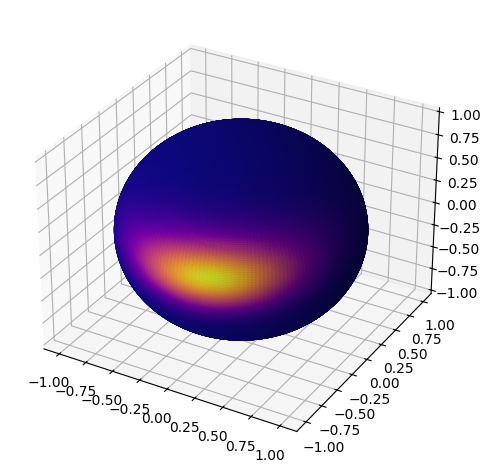

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from sphere.distribution import fb8


def grid(npts):
    return [_.flatten() for _ in np.meshgrid(np.linspace(0, np.pi, npts), np.linspace(0,2*np.pi, npts))]


def plot_fb8(fb8, npts):
    """
    Plot fb8 on 3D sphere
    """
    xs = fb8.spherical_coordinates_to_nu(*grid(npts))
    pdfs = fb8.pdf(xs)
    print(pdfs)
    z,x,y = xs.T #!!! Note the ordering for xs here is used consistently throughout. Follows Kent's 1982 paper.

    fig = plt.figure(figsize=plt.figaspect(1.))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x.reshape(npts, npts),
                    y.reshape(npts, npts),
                    z.reshape(npts, npts),
                    alpha=0.5,
                    rstride=1, cstride=1,
                    facecolors=cm.plasma(pdfs.reshape(npts, npts)/pdfs.max()))
    # ax.set_axis_off()
    # plt.tight_layout(-5)
    plt.tight_layout()
    plt.show()


plot_fb8(fb8(np.pi/16,-2.5*np.pi/1,0,10,10,-1,0.5,0.3), 200)

[4.32218706e-04 4.49655657e-04 4.69124397e-04 ... 1.06430356e-10
 9.54874301e-11 8.62386149e-11]


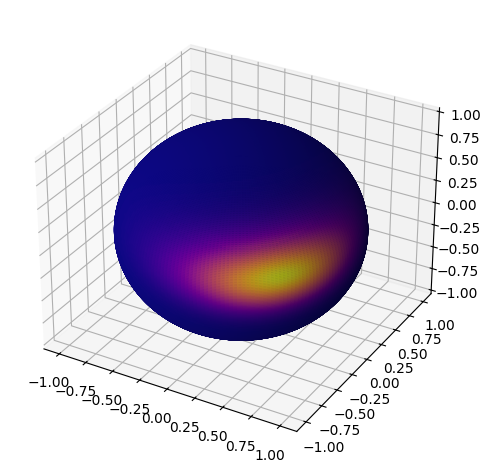

/home/jafertserrano/Desktop/U/Computation-/Python/.venv/lib/python3.11/site-packages/sphere/distribution/distribution.py:860: RuntimeWarning: invalid value encountered in sqrt
  x2 = sgn_0*np.sqrt(-radicalz(x1))/(2*m*x1*b+k*n1)


In [14]:
from sphere.distribution import fb8_mle
# plot_fb8(fb8(np.pi/16,-2.5*np.pi/1,0,0.00001,100,0.0001,0.5,0.3),200)


theta = np.pi/16
phi = -np.pi/3
psi = 0.0
kappa = 10
beta= 10
eta = -1
alpha = 0.5
rho = 0.3

plot_fb8(fb8(theta,phi,psi,kappa,beta,eta,alpha,rho),200)
xs = fb8(theta,phi,psi,kappa,beta,eta,alpha,rho).rvs(200)

In [21]:
func = fb8_mle(xs=xs)

[8.02574713e-05 8.94552497e-05 9.98556035e-05 ... 7.33773232e-11
 6.12915531e-11 5.14518355e-11]


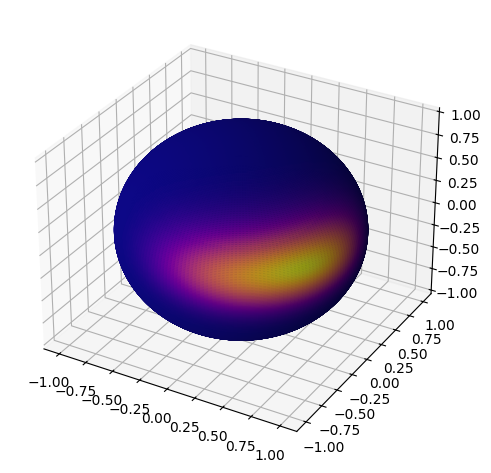

In [17]:
plot_fb8(func,200)